# Предобработка данных TAIGA: gamma vs proton

Цель работы: подготовить данные Хилласа к обучению моделей классификации частиц: `gamma` или `proton`.

В этой части работы нужно:

1. Считать CSV-файлы с данными.
2. Проверить структуру и качество данных.
3. Построить распределения признаков для классов `gamma` и `proton`.
4. Исследовать связь признаков с целевым классом.
5. Сформировать итоговый набор признаков для последующего обучения моделей.

## Словарь признаков для текущих CSV

Ниже приведена рабочая расшифровка признаков, которые есть в текущих файлах `data/gamma.csv` и `data/proton.csv` и соотносятся с PDF `Parameters_Definitions_Report.pdf`.

Важное ограничение: PDF описывает более полные экспериментальные таблицы TAIGA-IACT02, а текущие CSV являются сокращёнными таблицами признаков для задачи `gamma` vs `proton`. Поэтому информация из PDF подходит к нашим данным только частично. Хорошо применимы разделы про Hillas-параметры, моменты формы изображения и параметры клининга. В текущих CSV нет многих полей наблюдений, времени, pointing-файлов, фона и темпа счёта: `por`, `time`, `unix_time_ns`, `delta_time`, `error_deg`, `tel_az`, `tel_el`, `source_az`, `source_el`, `CR400phe`, `CR_portion`, `median_background`, `MAD_background`, `tel_ra`, `tel_dec`, `source_ra`, `source_dec`, `tracking`, `good`, `star`, `weather_mark`, `alpha_c`. Поэтому в этой работе используйте только фактически присутствующие колонки.

| Колонка в текущих CSV | Описание |
|---|---|
| `event_number` | Номер события. В PDF: `event_numb`. |
| `numb_pix` | Число пикселей, прошедших клининг. |
| `num_islands` | Число островов в событии после клининга. |
| `size` | Суммарное число фотоэлектронов в событии. |
| `Xc[0]` | X-координата центра тяжести события. |
| `Yc[0]` | Y-координата центра тяжести события. |
| `con_selected_island` | Доля `size` в отобранном самом ярком острове. |
| `con2` | Доля `size` в двух самых ярких пикселях события. |
| `length[0]` | Момент второго порядка вдоль главной оси эллипса. |
| `width[0]` | Момент второго порядка вдоль малой оси эллипса. |
| `dist[0]` | Расстояние между центром тяжести эллипса и положением источника. В PDF: `dist1`. |
| `dist[1]` | Расстояние между центром тяжести эллипса и положением антиисточника. В PDF: `dist2`. |
| `a_axis[0]` | Коэффициент `a` уравнения `y = a*x + b`, характеризующий наклон эллипса относительно координатной сетки камеры. |
| `b_axis[0]` | Коэффициент `b` уравнения `y = a*x + b`. Этого поля нет в исходной таблице описаний, но оно согласуется с описанием `a_axis`. |
| `skewness_l` | Асимметрия события вдоль главной оси эллипса. |
| `skewness_w` | Асимметрия события вдоль малой оси эллипса. |
| `skewness` | Асимметрия события. При анализе нужно проверить, как этот вариант названия соотносится с моментами вдоль осей. |
| `kurtosis_l` | Эксцесс вдоль главной оси. |
| `kurtosis_w` | Эксцесс вдоль малой оси. |
| `kurtosis` | Эксцесс события. При анализе нужно проверить, как этот вариант названия соотносится с моментами вдоль осей. |
| `alpha[0]` | Угол между главной осью эллипса и направлением на источник. В PDF: `alpha1`. |
| `alpha[1]` | Угол между главной осью эллипса и направлением на антиисточник. В PDF: `alpha2`. |
| `source_x` | X-координата источника в камере в градусах. |
| `source_y` | Y-координата источника в камере в градусах. |
| `edge` | Индикатор наличия граничных пикселей камеры среди пикселей, прошедших клининг. |

Колонки без надежного описания из предоставленного словаря, но присутствующие в данных: `clean_number`, `axis_scatter`, `energy`, `azwidth[1]`, `miss[1]`, `x_max_coord`, `y_max_coord`, `x_ground`, `y_ground`, `tel_tet`, `tel_fi`, `source_tet`, `source_fi`, `Xmax`, `con1`, `con3`.

Для итогового выбора признаков важно не только название, но и проверка распределений, пропусков, корреляций и возможной утечки информации.

## Как выполнять работу

- Выполняйте задания строго по порядку.
- В кодовых ячейках даны только подсказки по нужным методам и направлению решения. Рабочий код нужно написать самостоятельно.
- После каждого задания заполните блок `Промежуточный вывод`.
- Не ограничивайтесь фразой "видно на графике". Пишите, какие именно признаки отличаются и почему это важно для будущей модели.
- В конце работы должен получиться список признаков `selected_features`, который можно использовать в следующем ноутбуке для обучения моделей.

## Подготовка окружения

Импортируйте библиотеки, которые понадобятся для анализа таблиц и визуализации.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

## Задание 1. Считать CSV-данные

В папке `data` лежат два подготовленных CSV-файла:

- `gamma.csv` - события класса gamma;
- `proton.csv` - события класса proton.

Считайте оба файла в pandas DataFrame и посмотрите первые строки.

In [3]:
# Подсказки:
# 1. Создайте переменные с путями к файлам: data/gamma.csv и data/proton.csv.
# 2. Считайте оба файла с помощью pandas: pd.read_csv(...).
# 3. Сохраните таблицы в переменные gamma и proton.
# 4. Выведите размер таблиц через .shape.
# 5. Посмотрите первые строки через .head() или display(...).

# Ваш код:
gamma = pd.read_csv(r"C:\Users\HP\myproject\test_course\data\gamma.csv")
proton = pd.read_csv(r"C:\Users\HP\myproject\test_course\data\proton.csv")
df_gamma = gamma.copy()
df_proton = proton.copy()
print("The number of rows in gamma.csv is {0}, and the number of columns in train data is {1}".
      format(df_gamma.shape[0], df_gamma.shape[1]))
print("The number of rows in proton.csv is {0}, and the number of columns in train data is {1}".
      format(df_proton.shape[0], df_proton.shape[1]))
print("\n The first 10 rows of gamma.csv are: ")
print(df_gamma.head(n=10))
print("\n The first 10 rows of proton.csv are: ")
print(df_proton.head(n=10))

The number of rows in gamma.csv is 6218, and the number of columns in train data is 35
The number of rows in proton.csv is 5218, and the number of columns in train data is 39

 The first 10 rows of gamma.csv are: 
   clean_number  event_number  axis_scatter  numb_pix    energy      size     Xc[0]     Yc[0]      con2  length[0]  \
0             0             1             1        21  192.9010   903.418  1.369730 -2.416260  0.343822   0.706498   
1             1             1             4        24  192.9010  1388.880 -2.460750  0.711740  0.354539   0.698548   
2             2             1             7        13  192.9010   369.733 -0.612322 -3.264150  0.340513   0.551291   
3             3             1             9        13  192.9010   455.150  0.261173  3.177410  0.388384   0.542986   
4             4             2             1         5   30.2981   119.634 -2.490450 -0.030344  0.566160   0.381089   
5             5             2             7        14   30.2981   466.107 -1.6

### Промежуточный вывод 1

Заполните после выполнения кода:

- Сколько строк и колонок в каждом файле?
- Какие первые признаки вы видите в таблицах?
- Есть ли признаки, которые уже по названию выглядят как служебные или идентификаторы событий?

**Ваш вывод:**

>   - В gamma.csv 6218 строк и 35 колонок, в proton.csv 5218 строк и 39 колонок;
    - Gamma: clean_number  event_number  axis_scatter; Proton: clean_number  event_number  axis_scatter;
    - Gamma: clean_number  event_number; Proton: clean_number  event_number  axis_scatter.

## Задание 2. Объединить данные и добавить метку класса

Объедините данные `gamma` и `proton` в одну таблицу. Перед объединением добавьте информацию о классе события:

- `target = 0` для `gamma`;
- `target = 1` для `proton`.

После объединения сохраните результат в переменную `df`.

In [4]:
# Подсказки:
# 1. Сделайте копии таблиц gamma и proton через .copy().
# 2. Добавьте в каждую копию числовую колонку target.
# 3. Объедините таблицы через pd.concat(..., ignore_index=True).
# 4. Проверьте размер df и посмотрите несколько строк.

# Ваш код:
df_gamma["target"] = 0
df_proton["target"] = 1
df = pd.concat([df_gamma, df_proton], ignore_index = True)
df
print("The number of rows in df is {0}, and the number of columns is {1}".
      format(df.shape[0], df.shape[1]))
print("\n The first 10 rows of df are: ")
print(df.head(n=10))

The number of rows in df is 11436, and the number of columns is 42

 The first 10 rows of df are: 
   clean_number  event_number  axis_scatter  numb_pix    energy      size     Xc[0]     Yc[0]      con2  length[0]  \
0             0             1             1        21  192.9010   903.418  1.369730 -2.416260  0.343822   0.706498   
1             1             1             4        24  192.9010  1388.880 -2.460750  0.711740  0.354539   0.698548   
2             2             1             7        13  192.9010   369.733 -0.612322 -3.264150  0.340513   0.551291   
3             3             1             9        13  192.9010   455.150  0.261173  3.177410  0.388384   0.542986   
4             4             2             1         5   30.2981   119.634 -2.490450 -0.030344  0.566160   0.381089   
5             5             2             7        14   30.2981   466.107 -1.605750 -0.793270  0.416544   0.523761   
6             6             3             1        19  125.4810   705.492  

### Промежуточный вывод 2

Ответьте:

- Сколько строк получилось после объединения?
- Что означает значение `target = 0` и `target = 1`?
- Что вы заметили при первом просмотре объединённой таблицы?

**Ваш вывод:**

>   - 11436;
    - Не уверен, однако думаю это такой идентификатор двух массивов данных "Гамма" и "Протон";
    - Появились пропущенные данные ("Nan") в таких колонках как skewness_l  kurtosis_l  skewness_w  kurtosis_w  con1  con3

## Задание 3. Осмотреть структуру объединённой таблицы

Изучите структуру `df`: размеры, названия колонок, типы данных и несколько случайных строк. На этом этапе не исправляйте данные, а только зафиксируйте наблюдения.

In [5]:
# Подсказки:
# 1. Используйте .shape, .columns, .dtypes или .info().
# 2. Посмотрите первые, последние и случайные строки через .head(), .tail(), .sample().
# 3. Выпишите наблюдения, которые могут быть важны для дальнейшей предобработки.

# Ваш код:
print("Rows: ")
print(df.shape[0])
print("Columns: ")
print(df.columns)
print("Data types:")
print(df.dtypes)
print("First 3 rows:")
print(df.head(3))
print("\nLast 3 rows:")
print(df.tail(3))
print("\nRandom 3 rows:")
print(df.sample(3))


Rows: 
11436
Columns: 
Index(['clean_number', 'event_number', 'axis_scatter', 'numb_pix', 'energy', 'size', 'Xc[0]', 'Yc[0]', 'con2',
       'length[0]', 'width[0]', 'dist[0]', 'dist[1]', 'azwidth[1]', 'miss[1]', 'alpha[0]', 'alpha[1]', 'a_axis[0]',
       'b_axis[0]', 'x_max_coord', 'y_max_coord', 'skewness', 'kurtosis', 'edge', 'source_x', 'source_y', 'x_ground',
       'y_ground', 'tel_tet', 'tel_fi', 'source_tet', 'source_fi', 'Xmax', 'num_islands', 'con_selected_island',
       'target', 'skewness_l', 'kurtosis_l', 'skewness_w', 'kurtosis_w', 'con1', 'con3'],
      dtype='object')
Data types:
clean_number             int64
event_number             int64
axis_scatter             int64
numb_pix                 int64
energy                 float64
size                   float64
Xc[0]                  float64
Yc[0]                  float64
con2                   float64
length[0]              float64
width[0]               float64
dist[0]                float64
dist[1]                

### Промежуточный вывод 3

Ответьте:

- Какие типы данных есть в таблице?
- Какие колонки выглядят физическими признаками, а какие служебными?
- Какие особенности структуры таблицы нужно учесть перед выбором признаков?

**Ваш вывод:**

>   - int64, float64;
    - Служебные: clean_number  event_number  target. Физические: всё остальное;
    - Наличие пропущенных значений в колонках, разделение на target 0 и 1, два типа данных

## Задание 4. Проверить качество таблицы

Проверьте:

- баланс классов;
- типы данных;
- пропуски;
- полные дубликаты строк.

Эти проверки нужны до построения распределений и выбора признаков.

In [6]:
# Подсказки:
# 1. Посчитайте число объектов каждого класса через value_counts().
# 2. Посчитайте доли классов через value_counts(normalize=True).
# 3. Проверьте типы данных через .dtypes.
# 4. Найдите долю пропусков по колонкам через .isna().mean().
# 5. Проверьте полные дубликаты через .duplicated().sum().

# Ваш код:
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))
print("Data types: ")
print(df.dtypes)
print("\nMissing values :")
print(df.isna().mean())
print("\nDublicates: ")
print(df.duplicated().sum())

target
0    6218
1    5218
Name: count, dtype: int64
target
0    0.543722
1    0.456278
Name: proportion, dtype: float64
Data types: 
clean_number             int64
event_number             int64
axis_scatter             int64
numb_pix                 int64
energy                 float64
size                   float64
Xc[0]                  float64
Yc[0]                  float64
con2                   float64
length[0]              float64
width[0]               float64
dist[0]                float64
dist[1]                float64
azwidth[1]             float64
miss[1]                float64
alpha[0]               float64
alpha[1]               float64
a_axis[0]              float64
b_axis[0]              float64
x_max_coord            float64
y_max_coord            float64
skewness               float64
kurtosis               float64
edge                     int64
source_x               float64
source_y               float64
x_ground               float64
y_ground               float6

### Промежуточный вывод 4

Ответьте:

- Сильно ли отличаются размеры классов?
- Есть ли пропуски? Если есть, в каких колонках?
- Есть ли проблема с типами данных?
- Нужно ли сейчас удалять дубликаты или достаточно зафиксировать их наличие?

**Ваш вывод:**

>   - 54% у гамма квантов, ~46% у протонов - размеры классов сопоставимы;
    - lengh[0], width[0], a_axis[0], b_axis[0], skewness, kurtosis, skewness_l, kurtosis_l, skewness_w, kurtosis_w, con1, con3
    - Вроде нет
    - Я не выявил наличие дубликатов

## Задание 5. Выбрать числовые признаки для первичного анализа

Не все числовые колонки должны становиться признаками модели. Например, `target` - это целевая переменная, а `event_number` и `clean_number` похожи на идентификаторы.

На этом шаге сформируйте список числовых колонок, которые можно анализировать как потенциальные признаки.

In [14]:
# Подсказки:
# 1. Составьте список технических колонок, которые не должны быть признаками модели.
#    Например: target, event_number, clean_number.
# 2. Получите числовые колонки через select_dtypes(include="number").
# 3. Исключите технические колонки из списка числовых.
# 4. Сохраните результат в переменную numeric_columns.
# 5. Изучите описательные статистики через describe().

# Ваш код:
technical = df[["target", "clean_number", "event_number", "edge", "tel_tet", "tel_fi", "source_tet", "source_fi", "source_x", "source_y", "axis_scatter", "x_ground", "y_ground"]]
numeric_columns = df.select_dtypes(include="number").drop(columns=technical)

print(numeric_columns.describe())

           numb_pix        energy          size         Xc[0]         Yc[0]          con2     length[0]      width[0]  \
count  11436.000000  11436.000000  11436.000000  11436.000000  11436.000000  11436.000000  11433.000000  11433.000000   
mean      13.020811     59.409359    778.508505      0.032525      0.038650      0.450421      0.462816      0.149778   
std        7.950333     51.850892   1381.403504      1.786147      1.823893      0.123394      0.147151      0.040695   
min        4.000000      1.432260     42.972000     -4.104700     -3.970900      0.139075      0.112614      0.000000   
25%        8.000000     21.741700    176.051500     -1.417403     -1.453955      0.354226      0.347191      0.127230   
50%       11.000000     35.897900    330.722500      0.038649      0.020694      0.432309      0.451826      0.146419   
75%       16.000000     89.899800    747.003250      1.494722      1.539242      0.532190      0.572501      0.166896   
max      125.000000    199.82400

### Промежуточный вывод 5

Ответьте:

- Какие колонки вы исключили как технические?
- Все ли оставшиеся числовые колонки физически осмысленны как признаки?
- Есть ли признаки с очень разными масштабами значений?

**Ваш вывод:**

>   - Исключил все колонки не описывающие физические свойства события (Хилласа): идентификации события, указательные параметры телескопа и т.д;
    - Нет, количество засветившився пикселей numb_pix напрямую ничего не говорит о характере события, а miss[1] я просто не понял к чему отнести;
    - Да: energy, size, Xmax и высокие стат. моменты как skewness and kurtosis.

## Задание 6. Построить распределения признаков

Постройте распределения признаков отдельно для классов `gamma` и `proton`.

Начните с нескольких признаков, которые встречались в исследовательском ноутбуке: `width[0]`, `length[0]`, `alpha[0]`, `miss[1]`, `azwidth[1]`, `dist[1]`, `Xc[0]`, `Yc[0]`, `numb_pix`.

Затем добавьте 2-3 признака по своему выбору.

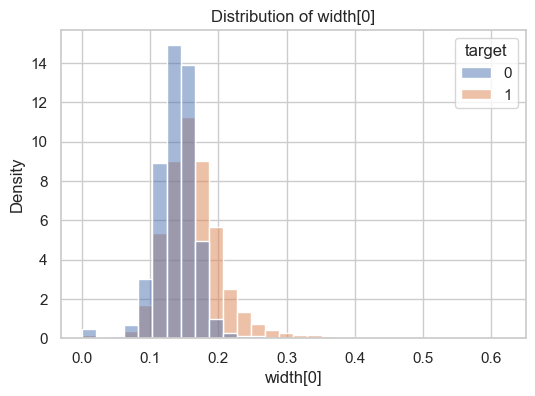

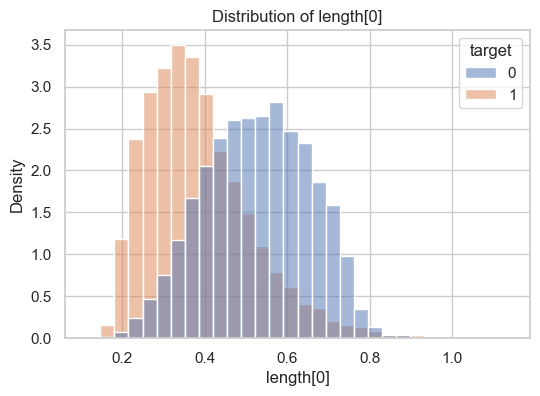

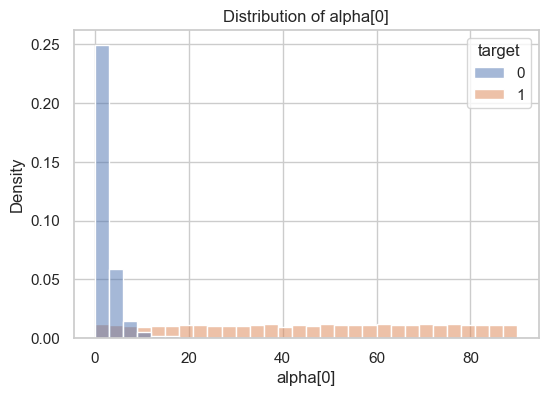

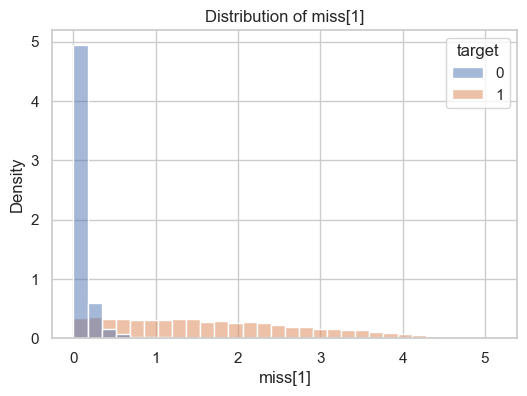

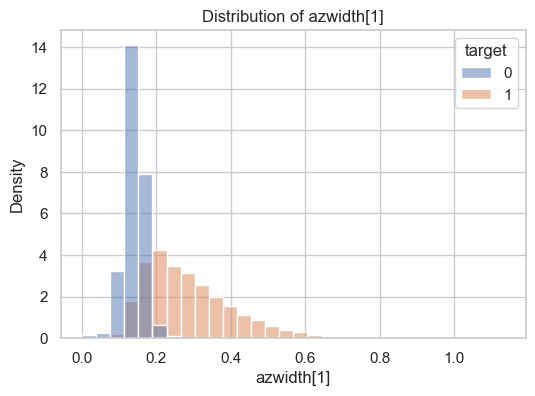

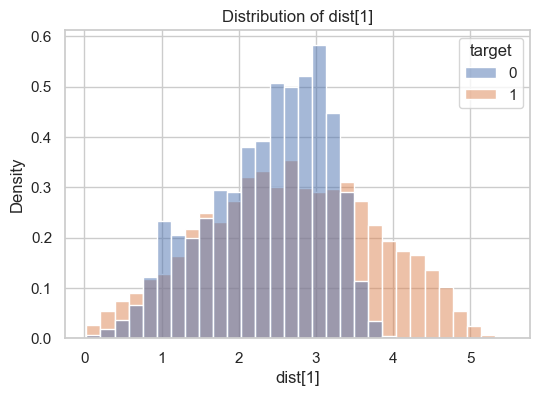

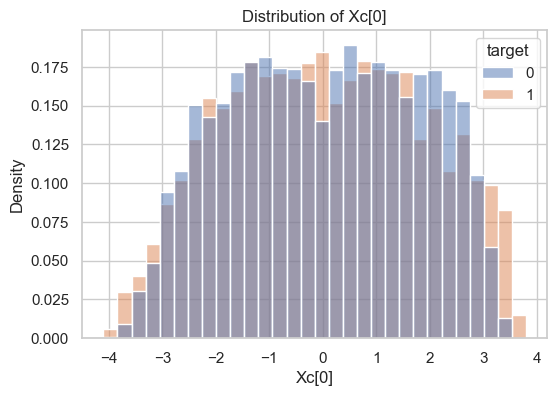

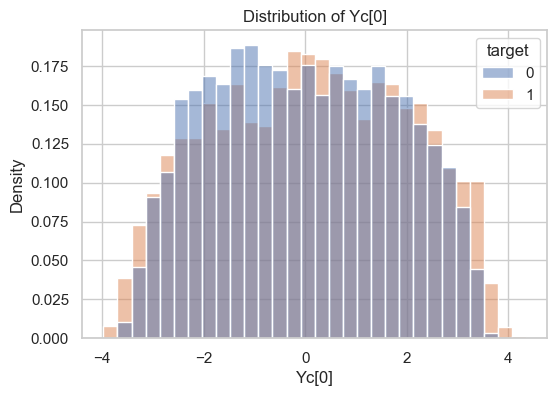

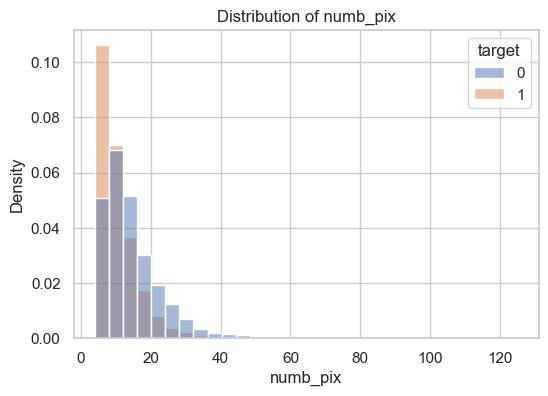

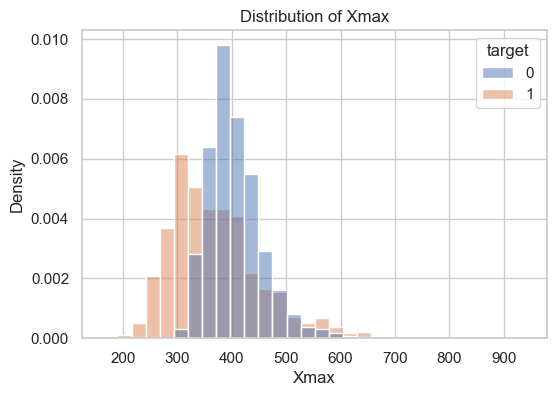

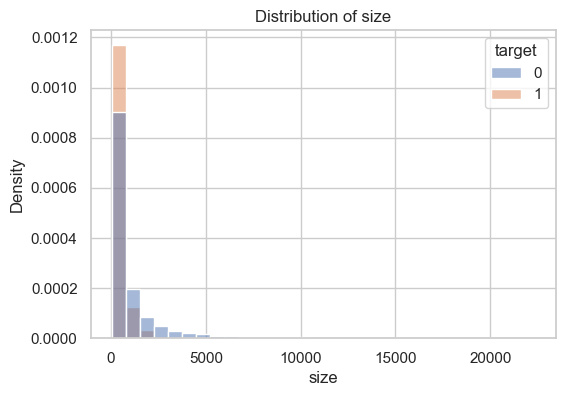

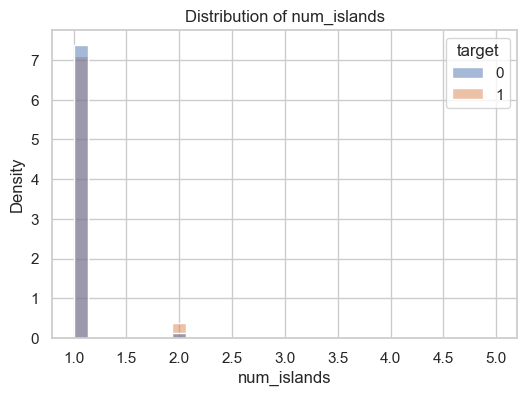

In [40]:
# Подсказки:
# 1. Создайте список features_to_plot с несколькими признаками для анализа.
#    Можно начать с width[0], length[0], alpha[0], miss[1], azwidth[1], dist[1], Xc[0], Yc[0], numb_pix.
# 2. Для каждого признака постройте распределение отдельно для gamma и proton.
# 3. Удобные функции: sns.histplot(..., hue="target") или sns.kdeplot(..., hue="target").
# 4. Настройте bins, alpha, stat="density" и common_norm=False, если используете histplot.
# 5. Подпишите графики и сравните формы распределений.

# Ваш код:
features_to_plot = ["width[0]", "length[0]", "alpha[0]", "miss[1]", "azwidth[1]", "dist[1]", "Xc[0]", "Yc[0]", "numb_pix", "Xmax", "size", "num_islands"]
for feature in features_to_plot:
    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=feature,
        hue="target",
        stat="density",
        common_norm=False,
        bins=30,
        alpha=0.5
    )

    plt.title(f"Distribution of {feature}")
    plt.show()

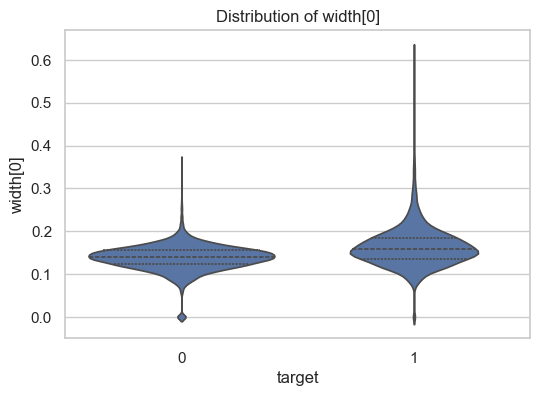

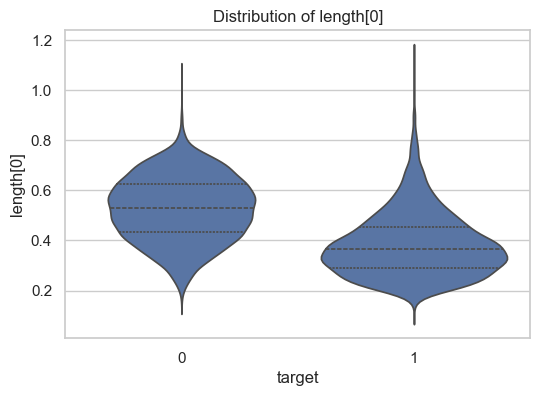

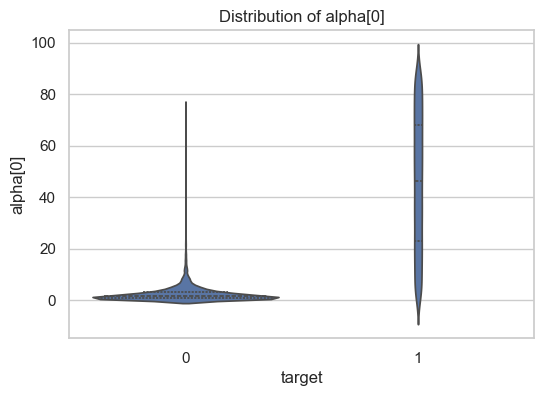

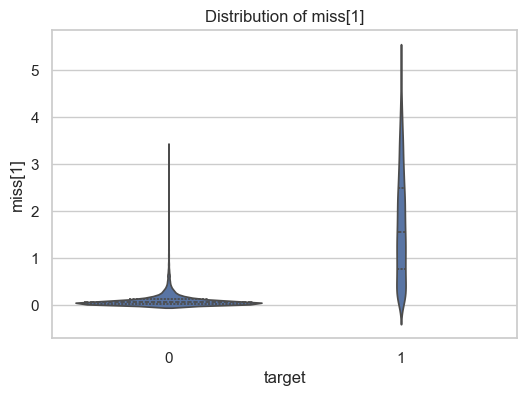

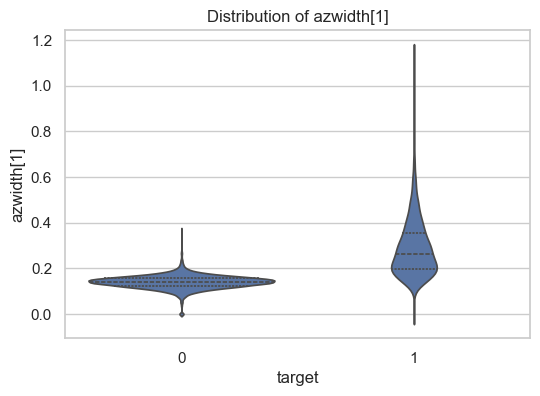

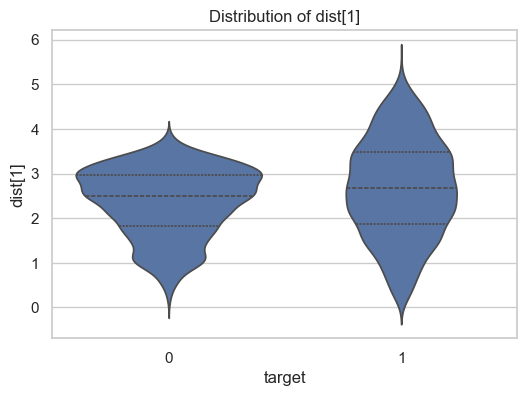

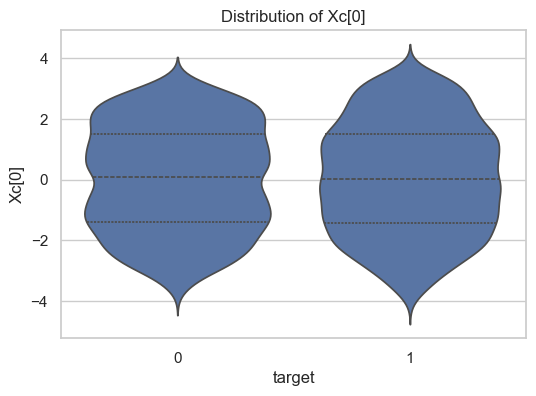

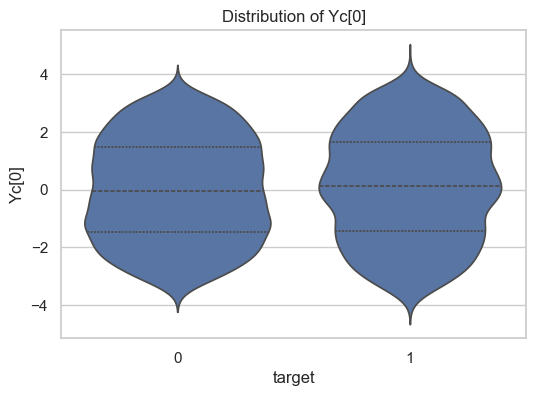

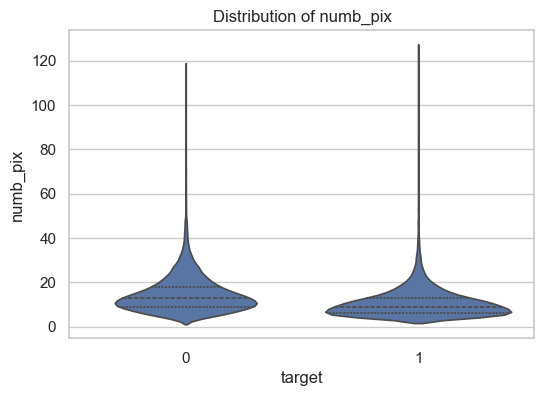

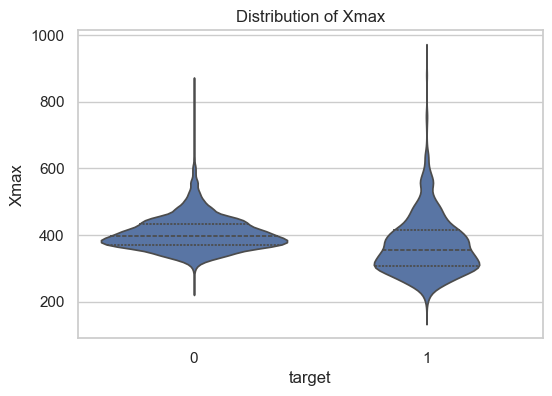

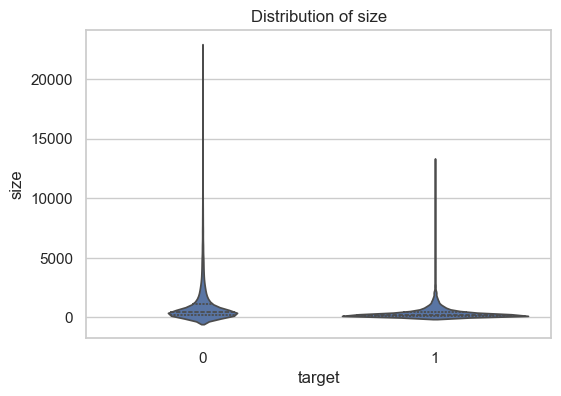

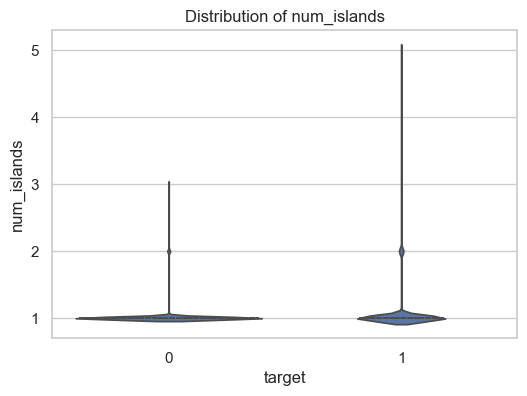

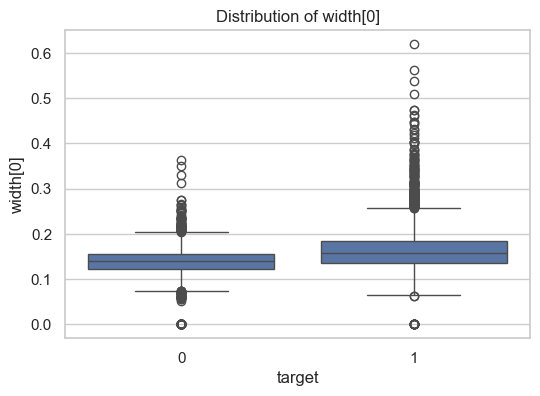

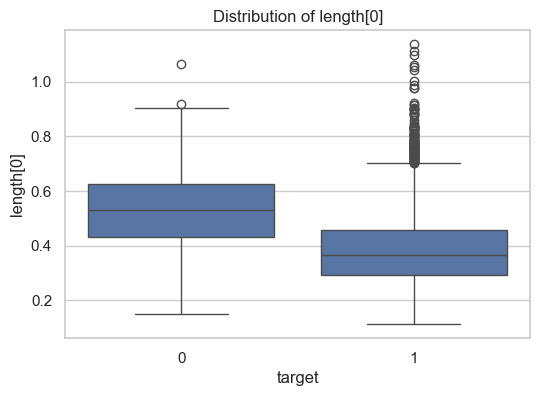

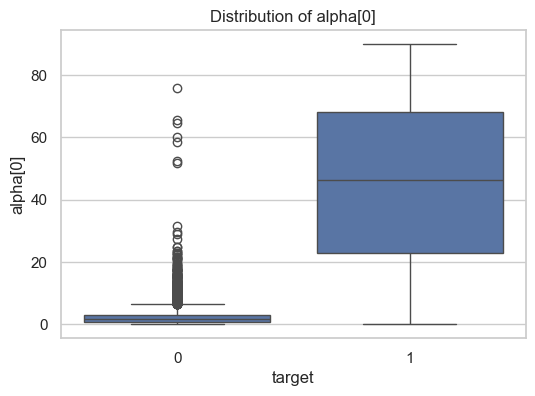

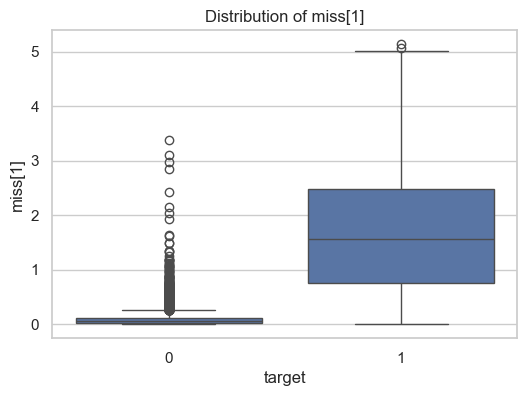

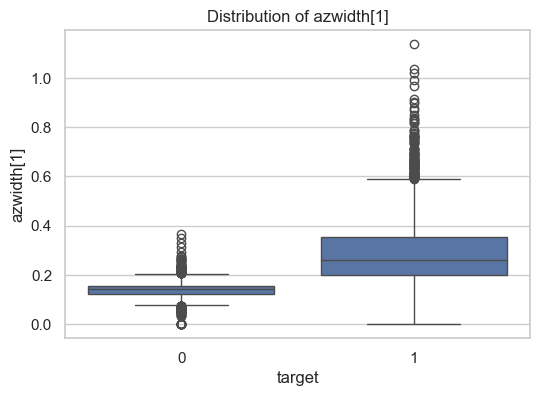

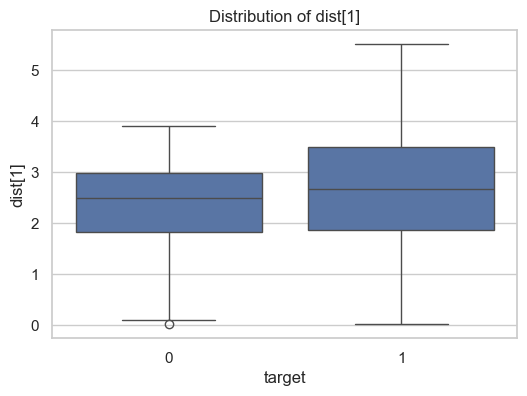

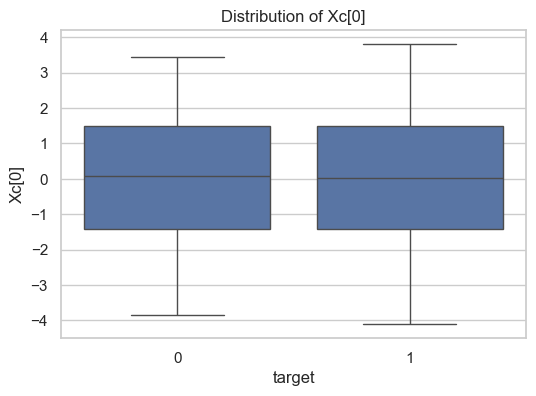

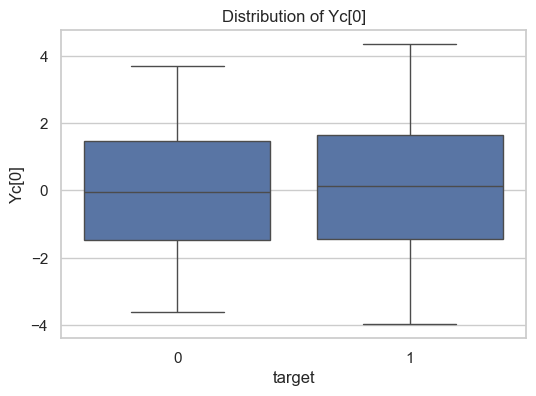

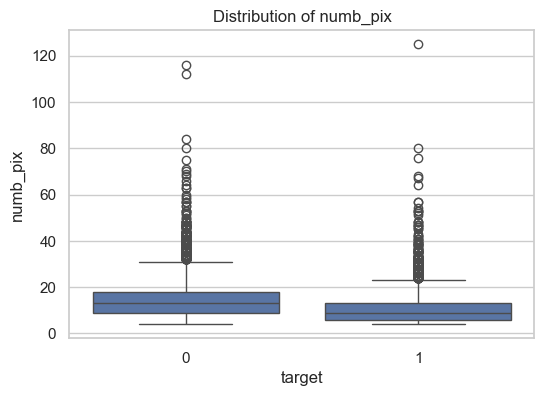

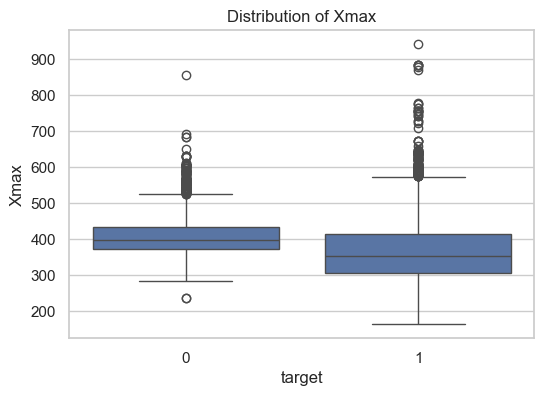

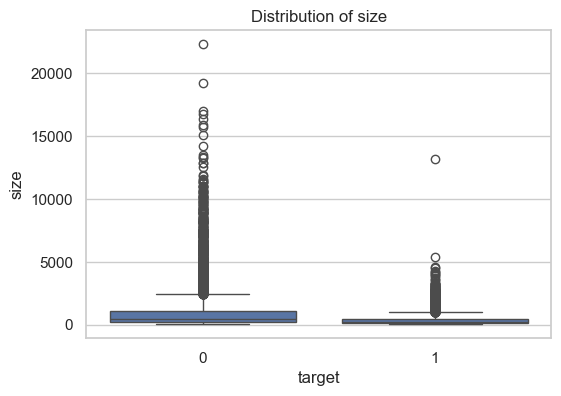

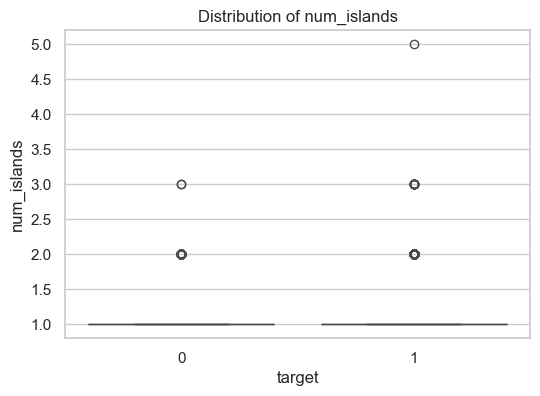

In [41]:
# Подсказки:
# 1. Постройте boxplot или violinplot для тех же признаков.
# 2. Удобные функции: sns.boxplot(data=df, x="target", y=feature) или sns.violinplot(...).
# 3. Используйте цикл по features_to_plot, если хотите построить несколько графиков.
# 4. Обратите внимание на медианы, разброс и выбросы.

# Ваш код:
for feature in features_to_plot:
    plt.figure(figsize=(6,4))

    sns.violinplot(
    data=df,
    x="target",
    y=feature,
    inner="quartile"
    )
    
    plt.title(f"Distribution of {feature}")
    plt.show()

for feature in features_to_plot:
    plt.figure(figsize=(6,4))

    sns.boxplot(
    data=df,
    x="target",
    y=feature
)
    
    plt.title(f"Distribution of {feature}")
    plt.show()

### Промежуточный вывод 6

Ответьте:

- Какие признаки имеют заметно разные распределения для `gamma` и `proton`?
- Какие признаки почти не разделяют классы визуально?
- Есть ли признаки с сильными выбросами?
- Какие признаки стоит оставить кандидатами для модели по итогам визуального анализа?

**Ваш вывод:**

>   - width[0], length[0], alpha[0] azwidth[1], miss[1], dist[1], Xmax
    - Да, центры масс (Xc[0], Yc[0]) количество пикселей numb_pix
    - Да, в количестве пикселей, ширине (и длине), alpha[0], miss[1]
    - width[0], length[0], alpha[0] azwidth[1], miss[1], dist[1], Xmax

## Задание 7. Исследовать корреляцию признаков с таргетом

Так как `target` закодирован числами `0` и `1`, обычная корреляция Пирсона между числовым признаком и `target` показывает линейную связь признака с классом.

Интерпретация:

- положительная корреляция: большие значения признака чаще соответствуют `proton`;
- отрицательная корреляция: большие значения признака чаще соответствуют `gamma`;
- корреляция около нуля не означает, что признак бесполезен: связь может быть нелинейной.

In [34]:
# Подсказки:
# 1. Посчитайте корреляцию каждого числового признака с df["target"].
# 2. Удобный метод: .corrwith(...).
# 3. Добавьте колонку с модулем корреляции, чтобы отсортировать признаки по силе связи.
# 4. Сохраните таблицу корреляций в переменную corr_with_target.
# 5. Выведите признаки с самой большой корреляцией по модулю.

# Ваш код:
corr_with_target = numeric_columns.corrwith(df["target"])
corr_with_target = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)
top_corr = corr_with_target.head(6)


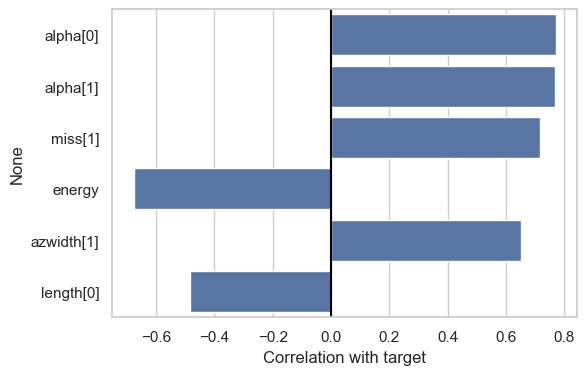

In [31]:
# Подсказки:
# 1. Возьмите top-N признаков из corr_with_target.
# 2. Постройте горизонтальный barplot корреляций.
# 3. Удобная функция: sns.barplot(...).
# 4. Добавьте вертикальную линию x=0 через plt.axvline(0).
# 5. Подпишите оси и заголовок.

# Ваш код:
plt.figure(figsize=(6,4))
sns.barplot(
    x=top_corr.values,
    y=top_corr.index
    )
plt.axvline(0, color="black")
plt.xlabel("Correlation with target")
plt.show()

### Промежуточный вывод 7

Ответьте:

- Какие признаки сильнее всего связаны с `target` по модулю корреляции?
- Какие признаки имеют положительную корреляцию с `target`, то есть больше характерны для `proton`?
- Какие признаки имеют отрицательную корреляцию с `target`, то есть больше характерны для `gamma`?
- Совпадают ли результаты корреляции с выводами по распределениям?

**Ваш вывод:**

>   - alpha[0], alpha[1], miss[1], energy, azwidth[1], length[0]
    - alpha[0], alpha[1], miss[1], azwidth[1]
    - energy, length
    - Нет, по расределением таккие ризнаки как alpha[0], azwidth[1], miss[1] сильнее коррелировали с гамма (таргет 0)

## Задание 8. Проверить корреляции между признаками

Если два признака почти полностью повторяют друг друга, модель может не получить от них новой информации. Постройте тепловую карту корреляций между наиболее перспективными признаками.

Сначала выберите признаки с наибольшей связью с `target`, затем посмотрите, нет ли среди них сильно коррелирующих пар.

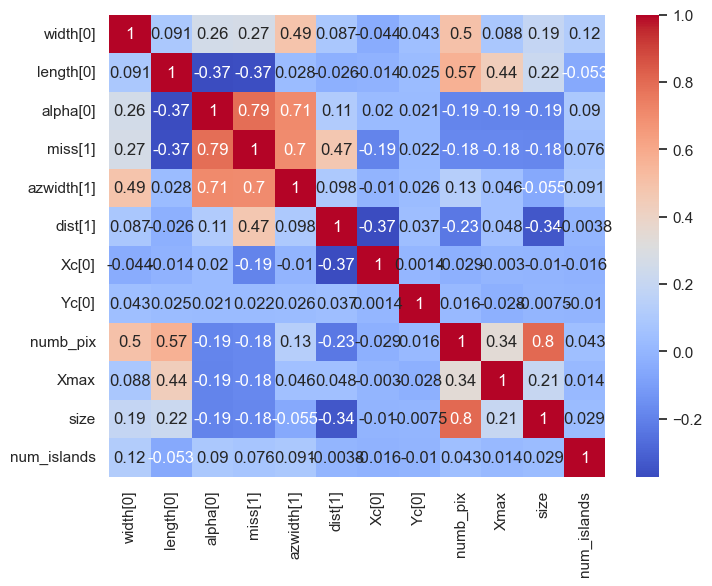

In [42]:
# Подсказки:
# 1. Выберите 10-15 наиболее перспективных признаков.
# 2. Посчитайте матрицу корреляций между ними через .corr().
# 3. Постройте heatmap через sns.heatmap(...).
# 4. Найдите пары признаков с очень высокой корреляцией между собой.

# Ваш код:
features = df[features_to_plot]

corr_m = features.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_m, annot=True, cmap="coolwarm")
plt.show()

### Промежуточный вывод 8

Ответьте:

- Есть ли пары признаков с очень высокой корреляцией между собой?
- Нужно ли удалять один из таких признаков уже сейчас или лучше оставить решение до этапа обучения моделей?
- Какие признаки после этого шага остаются наиболее перспективными?

**Ваш вывод:**

>   - Да: alpha[0] && miss[1], alpha[0] && azwidth[1], miss[1] && azwidth[1], azwidth[1] && width[0], numb_pix && length[0], numb_pix && size
    - Такие пары как numb_pix и size, по моему мнению, лучше удалять сразу 
    - alpha[0], miss[1], azwidth[1], lenght[0], alpha[0]

## Задание 9. Сформировать итоговый набор признаков

Соберите итоговый список `selected_features` для следующей работы с моделями.

Критерии выбора:

- признак есть и у `gamma`, и у `proton`;
- признак числовой;
- признак не является `target` или идентификатором события;
- распределения признака отличаются между классами или есть заметная связь с `target`;
- если признак исключен, вы можете объяснить почему.

In [44]:
# Подсказки:
# 1. Создайте список selected_features вручную по итогам предыдущих заданий.
# 2. В список должны попасть только признаки, которые есть в df и подходят для модели.
# 3. Не включайте target и идентификаторы событий.
# 4. Проверьте список: все выбранные признаки должны быть в numeric_columns.
# 5. Выведите итоговый список и его длину.

# Ваш код:
selected_features = [
    "alpha[0]", "miss[1]", "azwidth[1]", "lenght[0]", "width[0]", "numb_pix"
]
print(f"The selected columns for learning is {selected_features} with length {len(selected_features)}")


The selected columns for learning is ['alpha[0]', 'miss[1]', 'azwidth[1]', 'lenght[0]', 'width[0]', 'numb_pix'] with length 6


## Итоговый вывод

Заполните в конце работы:

1. Какие файлы были считаны и как был задан `target`?
2. Какие признаки визуально лучше всего разделяют `gamma` и `proton`?
3. Какие признаки сильнее всего коррелируют с `target`?
4. Какие признаки были исключены и почему?
5. Какой итоговый список `selected_features` вы предлагаете использовать для обучения моделей?

**Ваш итоговый вывод:**

>   1 Были считаны два файла: gamma.csv и proton.csv, target был задан 0 к gamma 1 к proton;
    2 length-to-width ratio, numb_islands
    3 alpha[0] alpha[1] azwidth[1], miss[1]
    4 Были исключены чисто технические признаки либо слабокореллирующие со всеми другими ризнаки
    5 Сисок с шестью признаками ('alpha[0]', 'miss[1]', 'azwidth[1]', 'lenght[0]', 'width[0]', 'numb_pix') сильно кореллирующими с друг другомю